# Probing Classifiers: From Linear Probes to Causal Validation

**Survey Reference:** Section 8.6 - Probing Classifiers: Capabilities, Critiques, and Causal Limitations

## Overview

**Probing classifiers** (probes) are trained to predict properties from neural network representations. If a linear probe can accurately classify some property from activations, that property is linearly represented in the model's internal state.

The core idea is simple: extract internal activations from a model, then train a simple classifier on them. But the implications are deep -- if we can reliably read off truth, deception, or intent from model internals, there are direct applications for AI safety monitoring.

From the [Geometry of Truth](https://arxiv.org/abs/2310.06824) paper (Marks & Tegmark, COLM 2024):

> *"We identify a linear representation of truth that generalizes across several structurally and topically diverse datasets... these representations are not merely associated with truth, but are also causally implicated in the model's output."*

The "causally implicated" part matters: it's not just that we *can* read off truth from model internals, but that the model actually *uses* these representations when computing outputs. We verify this in Section 6.

### Why this matters for safety

[Neel Nanda argues](https://www.lesswrong.com/posts/G9HdpyREaCbFJjKu5/it-is-reasonable-to-research-how-to-use-model-internals-in) probes could be used during training: *"There are certain things that may be much easier to specify using the internals of the model. For example: Did it do something for the right reasons? Did it only act this way because it knew it was being trained or watched?"*

But this is genuinely controversial. The worry is that training against probe signals might teach the model to hide whatever the probe measures: *"If you train directly against non-obfuscated internals and no longer see bad behavior, the obvious possibility is that now you've just got obfuscated internals."*

### What we build

These exercises cover the full pipeline: extracting activations, visualizing with PCA, training probes, validating them causally, and applying them to deception detection. We use GPT-2 for the core probing sections (1-7) and a small instruct model for deception probing (Section 8).

## Learning Objectives

1. Extract hidden state activations and visualize truth representations with PCA
2. Understand which layers best represent truth via a layer sweep
3. Train and compare difference-of-means (MM) and logistic regression (LR) probes
4. Use control tasks and selectivity to validate probe results
5. Implement causal interventions (activation patching) to prove representations are causally used
6. Apply amnesic probing to remove information from representations
7. Train deception probes on an instruct-tuned model using instructed-pairs methodology
8. Implement attention probes for sequence-level classification

## Key References

- [The Geometry of Truth](https://arxiv.org/abs/2310.06824) -- Marks & Tegmark (COLM 2024). Linear truth representations that generalize across datasets.
- [Detecting Strategic Deception Using Linear Probes](https://arxiv.org/abs/2502.03407) -- Goldowsky-Dill et al. (Apollo Research, 2025). Probes trained on simple contrastive data generalize to realistic deception.
- [Detecting High-Stakes Interactions with Activation Probes](https://arxiv.org/abs/2506.10805) -- McKenzie et al. (NeurIPS 2025). Attention probes match LLM classifiers at a fraction of the compute.
- [Discovering Latent Knowledge Without Supervision](https://arxiv.org/abs/2212.03827) -- Burns et al. (ICLR 2023). CCS: unsupervised truth direction discovery.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Setup and Datasets

We use GPT-2 (124M parameters, 12 layers, 768-dim hidden states) throughout sections 1-7. It's small enough to run on CPU but large enough to develop interesting internal representations.

For probing, we need datasets of true/false factual statements. We create three datasets inspired by the [Geometry of Truth](https://arxiv.org/abs/2310.06824) paper's format: each statement ends with a period and has a binary label (1 = true, 0 = false). The datasets are topically and structurally diverse so we can test whether truth probes generalize across domains.

In [2]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

NUM_LAYERS = model.config.n_layer
D_MODEL = model.config.n_embd

print(f"Model: {model_name}")
print(f"Layers: {NUM_LAYERS}, Hidden dim: {D_MODEL}")

Model: gpt2
Layers: 12, Hidden dim: 768


### True/False Datasets

We create three topically diverse datasets following the Geometry of Truth paper's format. Each contains paired true/false statements so we can later test whether probes find a *universal* truth direction or just dataset-specific features.

In [3]:
cities_true = [
    "The city of Paris is in France.", "The city of Tokyo is in Japan.",
    "The city of Berlin is in Germany.", "The city of Rome is in Italy.",
    "The city of Madrid is in Spain.", "The city of London is in England.",
    "The city of Cairo is in Egypt.", "The city of Moscow is in Russia.",
    "The city of Beijing is in China.", "The city of Seoul is in South Korea.",
    "The city of Athens is in Greece.", "The city of Lisbon is in Portugal.",
    "The city of Bangkok is in Thailand.", "The city of Dublin is in Ireland.",
    "The city of Vienna is in Austria.", "The city of Warsaw is in Poland.",
    "The city of Ottawa is in Canada.", "The city of Lima is in Peru.",
    "The city of Nairobi is in Kenya.", "The city of Hanoi is in Vietnam.",
]
cities_false = [
    "The city of Paris is in Germany.", "The city of Tokyo is in China.",
    "The city of Berlin is in France.", "The city of Rome is in Spain.",
    "The city of Madrid is in Italy.", "The city of London is in France.",
    "The city of Cairo is in India.", "The city of Moscow is in Poland.",
    "The city of Beijing is in Japan.", "The city of Seoul is in Thailand.",
    "The city of Athens is in Turkey.", "The city of Lisbon is in Spain.",
    "The city of Bangkok is in Vietnam.", "The city of Dublin is in Scotland.",
    "The city of Vienna is in Germany.", "The city of Warsaw is in Russia.",
    "The city of Ottawa is in Australia.", "The city of Lima is in Brazil.",
    "The city of Nairobi is in Nigeria.", "The city of Hanoi is in Cambodia.",
]

comparisons_true = [
    "89 is greater than 12.", "150 is greater than 30.", "500 is greater than 100.",
    "73 is greater than 14.", "200 is greater than 50.", "999 is greater than 111.",
    "45 is greater than 9.", "320 is greater than 80.", "67 is greater than 23.",
    "1000 is greater than 500.", "88 is greater than 17.", "250 is greater than 60.",
    "400 is greater than 90.", "55 is greater than 11.", "700 is greater than 200.",
    "33 is greater than 8.", "180 is greater than 40.", "95 is greater than 20.",
    "600 is greater than 150.", "77 is greater than 16.",
]
comparisons_false = [
    "12 is greater than 89.", "30 is greater than 150.", "100 is greater than 500.",
    "14 is greater than 73.", "50 is greater than 200.", "111 is greater than 999.",
    "9 is greater than 45.", "80 is greater than 320.", "23 is greater than 67.",
    "500 is greater than 1000.", "17 is greater than 88.", "60 is greater than 250.",
    "90 is greater than 400.", "11 is greater than 55.", "200 is greater than 700.",
    "8 is greater than 33.", "40 is greater than 180.", "20 is greater than 95.",
    "150 is greater than 600.", "16 is greater than 77.",
]

animals_true = [
    "A cat is a mammal.", "A dog is a mammal.", "A whale is a mammal.",
    "A snake is a reptile.", "A frog is an amphibian.", "An eagle is a bird.",
    "A salmon is a fish.", "A spider is an arachnid.", "A dolphin is a mammal.",
    "A lizard is a reptile.", "A penguin is a bird.", "A shark is a fish.",
    "A horse is a mammal.", "A turtle is a reptile.", "A bat is a mammal.",
    "An owl is a bird.", "A crocodile is a reptile.", "A bear is a mammal.",
    "A parrot is a bird.", "A rabbit is a mammal.",
]
animals_false = [
    "A cat is a reptile.", "A dog is a bird.", "A whale is a fish.",
    "A snake is a mammal.", "A frog is a reptile.", "An eagle is a mammal.",
    "A salmon is a reptile.", "A spider is an insect.", "A dolphin is a fish.",
    "A lizard is a mammal.", "A penguin is a fish.", "A shark is a mammal.",
    "A horse is a reptile.", "A turtle is an amphibian.", "A bat is a bird.",
    "An owl is a reptile.", "A crocodile is a mammal.", "A bear is a reptile.",
    "A parrot is a mammal.", "A rabbit is a bird.",
]

DATASET_NAMES = ["cities", "comparisons", "animals"]

datasets = {}
for name, true_stmts, false_stmts in [
    ("cities", cities_true, cities_false),
    ("comparisons", comparisons_true, comparisons_false),
    ("animals", animals_true, animals_false),
]:
    statements = true_stmts + false_stmts
    labels = [1] * len(true_stmts) + [0] * len(false_stmts)
    datasets[name] = {"statements": statements, "labels": torch.tensor(labels, dtype=torch.float32)}
    print(f"{name}: {len(statements)} statements ({sum(labels)} true, {len(labels) - sum(labels)} false)")
    print(f"  Example true:  {true_stmts[0]}")
    print(f"  Example false: {false_stmts[0]}\n")

cities: 40 statements (20 true, 20 false)
  Example true:  The city of Paris is in France.
  Example false: The city of Paris is in Germany.

comparisons: 40 statements (20 true, 20 false)
  Example true:  89 is greater than 12.
  Example false: 12 is greater than 89.

animals: 40 statements (20 true, 20 false)
  Example true:  A cat is a mammal.
  Example false: A cat is a reptile.



In [4]:
def extract_activations(
    statements: list[str],
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    layers: list[int],
    batch_size: int = 16,
) -> dict[int, torch.Tensor]:
    """
    Extract last-token hidden state activations from specified layers.

    outputs.hidden_states has length num_layers + 1: index 0 is the embedding
    output, index i >= 1 is the output of transformer layer i-1. We handle
    padding by extracting the activation at the last *real* token per sequence.

    Returns dict mapping layer index -> tensor of shape [n_statements, d_model].
    """
    all_acts = {layer: [] for layer in layers}

    for i in range(0, len(statements), batch_size):
        batch = statements[i : i + batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", padding=True, truncation=True, max_length=512
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        last_token_idx = inputs["attention_mask"].sum(dim=1) - 1
        batch_indices = torch.arange(len(batch), device=model.device)

        for layer in layers:
            hidden = outputs.hidden_states[layer + 1]
            acts = hidden[batch_indices, last_token_idx]
            all_acts[layer].append(acts.cpu().float())

    return {layer: torch.cat(tensors, dim=0) for layer, tensors in all_acts.items()}

In [5]:
PROBE_LAYER = NUM_LAYERS // 2  # middle layer as default probe point

activations = {}
labels_dict = {}

for name in DATASET_NAMES:
    acts = extract_activations(
        datasets[name]["statements"], model, tokenizer, layers=[PROBE_LAYER]
    )
    activations[name] = acts[PROBE_LAYER]
    labels_dict[name] = datasets[name]["labels"]
    print(f"{name}: activations shape {activations[name].shape}")

cities: activations shape torch.Size([40, 768])
comparisons: activations shape torch.Size([40, 768])
animals: activations shape torch.Size([40, 768])


## 2. Visualizing Truth Representations with PCA

PCA is completely unsupervised -- it finds the directions of maximum variance without any knowledge of labels. If we see separation by true/false label in PCA space, it means truth is one of the most prominent features in the model's representation space.

Before running the next cell, consider: the activations live in a 768-dimensional space. There are many features competing for variance (syntax, semantics, topic, etc.). Do you expect truth to be prominent enough for PCA to pick up on?

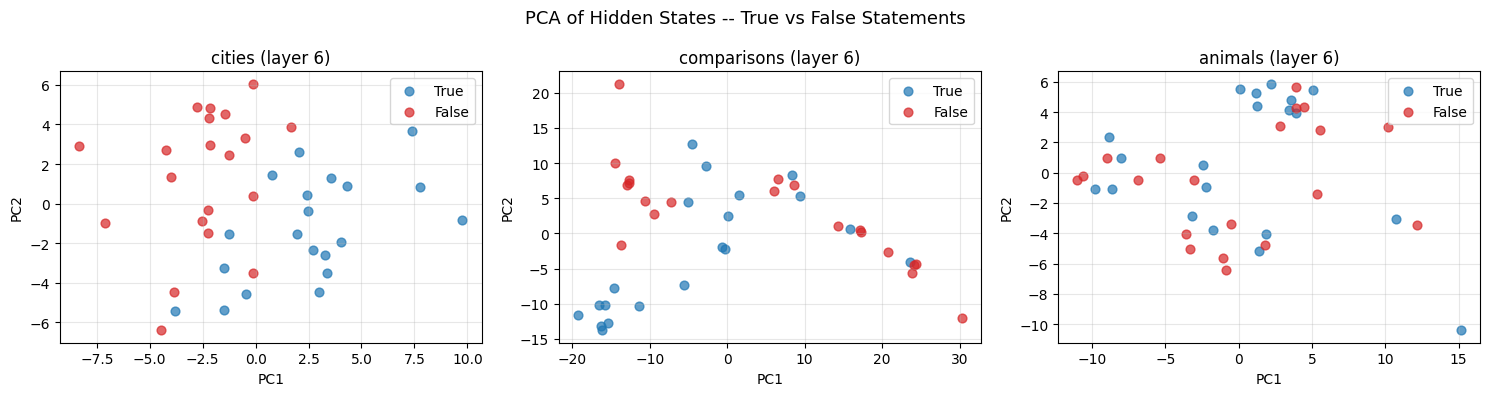

In [6]:
def get_pca_components(activations: torch.Tensor, k: int = 2) -> torch.Tensor:
    """
    Compute top-k principal components via eigendecomposition.

    Returns matrix of shape [d_model, k] with top-k eigenvectors as columns.
    """
    X = activations - activations.mean(dim=0)
    cov = X.t() @ X / (X.shape[0] - 1)
    eigenvalues, eigenvectors = torch.linalg.eigh(cov)
    sorted_indices = torch.argsort(eigenvalues, descending=True)
    return eigenvectors[:, sorted_indices[:k]]


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, name in enumerate(DATASET_NAMES):
    acts = activations[name]
    labels = labels_dict[name]

    pca_dirs = get_pca_components(acts, k=2)
    projected = (acts - acts.mean(dim=0)) @ pca_dirs

    true_mask = labels == 1
    false_mask = labels == 0
    axes[idx].scatter(
        projected[true_mask, 0], projected[true_mask, 1],
        c="tab:blue", label="True", alpha=0.7, s=40
    )
    axes[idx].scatter(
        projected[false_mask, 0], projected[false_mask, 1],
        c="tab:red", label="False", alpha=0.7, s=40
    )
    axes[idx].set_title(f"{name} (layer {PROBE_LAYER})")
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2")
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle("PCA of Hidden States -- True vs False Statements", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Layer Sweep: Where Does Truth Live?

Not all layers represent truth equally. The Geometry of Truth paper found truth representations concentrated in early-to-mid layers. We verify this by training a simple difference-of-means classifier at every layer and measuring accuracy.

The difference-of-means classifier works as follows: compute `direction = mean(true_acts) - mean(false_acts)`, then classify a new activation by the sign of its dot product with this direction.

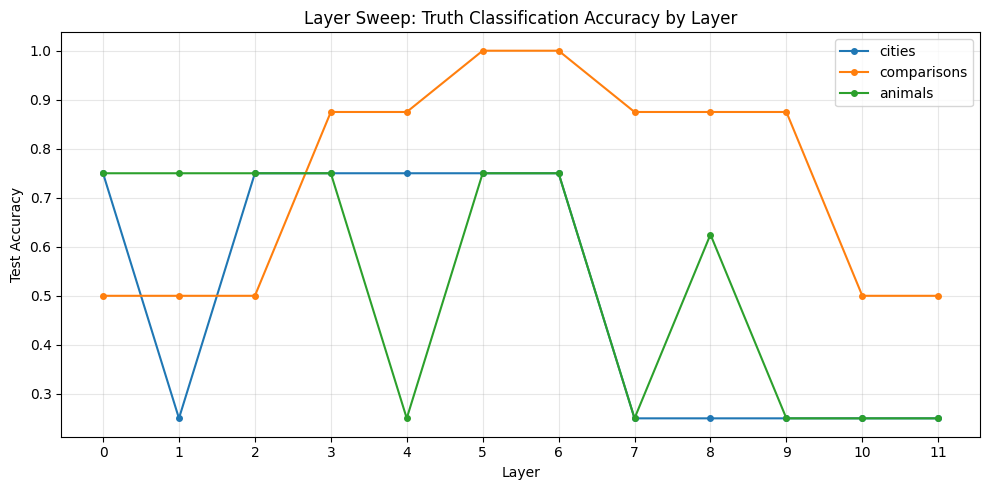

In [7]:
def layer_sweep_accuracy(
    statements: list[str],
    labels: torch.Tensor,
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    layers: list[int],
    train_frac: float = 0.8,
) -> dict[str, list[float]]:
    """
    For each layer, train a difference-of-means classifier and return train/test accuracy.
    """
    n_train = int(len(statements) * train_frac)
    perm = torch.randperm(len(statements))
    train_idx, test_idx = perm[:n_train], perm[n_train:]

    train_stmts = [statements[i] for i in train_idx]
    test_stmts = [statements[i] for i in test_idx]
    train_labels = labels[train_idx]
    test_labels = labels[test_idx]

    train_acts = extract_activations(train_stmts, model, tokenizer, layers)
    test_acts = extract_activations(test_stmts, model, tokenizer, layers)

    train_accs, test_accs = [], []
    for layer in layers:
        pos = train_acts[layer][train_labels == 1]
        neg = train_acts[layer][train_labels == 0]
        direction = pos.mean(0) - neg.mean(0)

        train_preds = ((train_acts[layer] @ direction) > 0).float()
        test_preds = ((test_acts[layer] @ direction) > 0).float()

        train_accs.append((train_preds == train_labels).float().mean().item())
        test_accs.append((test_preds == test_labels).float().mean().item())

    return {"train_acc": train_accs, "test_acc": test_accs}


torch.manual_seed(42)
all_layers = list(range(NUM_LAYERS))

fig, ax = plt.subplots(figsize=(10, 5))
for name in DATASET_NAMES:
    result = layer_sweep_accuracy(
        datasets[name]["statements"], datasets[name]["labels"],
        model, tokenizer, all_layers
    )
    ax.plot(all_layers, result["test_acc"], marker="o", label=name, markersize=4)

ax.set_xlabel("Layer")
ax.set_ylabel("Test Accuracy")
ax.set_title("Layer Sweep: Truth Classification Accuracy by Layer")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(all_layers)
plt.tight_layout()
plt.show()

## 4. Training and Comparing Probes

We implement two probe types from the Geometry of Truth paper:

- **MMProbe** (Mass-Mean / Difference-of-Means): the truth direction is simply `mean(true) - mean(false)`. Classify by `sigmoid(x @ direction)`.
- **LRProbe** (Logistic Regression): a linear classifier trained via sklearn. Finds the optimal separating hyperplane with L2 regularization.

Both produce a single direction vector in activation space. The paper reports similar classification accuracies for both, but (as we'll see in Section 6) the *causally meaningful* direction differs.

> *"We find that the difference-in-means directions are more causally implicated in the model's computation of truth values than the logistic regression directions, despite the fact that they achieve similar accuracies when used as probes."* -- Marks & Tegmark, 2024

In [8]:
torch.manual_seed(42)
train_acts, test_acts = {}, {}
train_labels, test_labels = {}, {}

for name in DATASET_NAMES:
    acts = activations[name]
    labs = labels_dict[name]
    n = len(acts)
    perm = torch.randperm(n)
    n_train = int(0.8 * n)

    train_acts[name] = acts[perm[:n_train]]
    test_acts[name] = acts[perm[n_train:]]
    train_labels[name] = labs[perm[:n_train]]
    test_labels[name] = labs[perm[n_train:]]
    print(f"{name}: train={n_train}, test={n - n_train}")

cities: train=32, test=8
comparisons: train=32, test=8
animals: train=32, test=8


In [9]:
class MMProbe(nn.Module):
    """Mass-Mean (difference-of-means) probe. The simplest and often most causally meaningful probe."""

    def __init__(self, direction: torch.Tensor):
        super().__init__()
        self.direction = nn.Parameter(direction, requires_grad=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(x @ self.direction)

    def pred(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).round()

    @staticmethod
    def from_data(acts: torch.Tensor, labels: torch.Tensor) -> "MMProbe":
        pos_mean = acts[labels == 1].mean(0)
        neg_mean = acts[labels == 0].mean(0)
        direction = pos_mean - neg_mean
        return MMProbe(direction)


class LRProbe(nn.Module):
    """Logistic regression probe with StandardScaler normalization."""

    def __init__(self, d_in: int, scaler_mean=None, scaler_scale=None):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, 1, bias=False), nn.Sigmoid())
        self.register_buffer("scaler_mean", scaler_mean)
        self.register_buffer("scaler_scale", scaler_scale)

    def _normalize(self, x: torch.Tensor) -> torch.Tensor:
        if self.scaler_mean is not None and self.scaler_scale is not None:
            return (x - self.scaler_mean) / self.scaler_scale
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(self._normalize(x)).squeeze(-1)

    def pred(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).round()

    @property
    def direction(self) -> torch.Tensor:
        return self.net[0].weight.data[0]

    @staticmethod
    def from_data(acts: torch.Tensor, labels: torch.Tensor, C: float = 0.1) -> "LRProbe":
        X_np = acts.numpy()
        y_np = labels.numpy()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_np)

        lr = LogisticRegression(C=C, fit_intercept=False, max_iter=1000)
        lr.fit(X_scaled, y_np)

        d_in = acts.shape[1]
        probe = LRProbe(
            d_in,
            scaler_mean=torch.tensor(scaler.mean_, dtype=torch.float32),
            scaler_scale=torch.tensor(scaler.scale_, dtype=torch.float32),
        )
        probe.net[0].weight.data[0] = torch.tensor(lr.coef_[0], dtype=torch.float32)
        return probe

In [10]:
print(f"{'Dataset':<15} {'MMProbe':>10} {'LRProbe':>10}")
print("-" * 37)

mm_probes, lr_probes = {}, {}
for name in DATASET_NAMES:
    mm = MMProbe.from_data(train_acts[name], train_labels[name])
    lr = LRProbe.from_data(train_acts[name], train_labels[name])
    mm_probes[name] = mm
    lr_probes[name] = lr

    mm_acc = (mm.pred(test_acts[name]) == test_labels[name]).float().mean().item()
    lr_acc = (lr.pred(test_acts[name]) == test_labels[name]).float().mean().item()
    print(f"{name:<15} {mm_acc:>10.3f} {lr_acc:>10.3f}")

Dataset            MMProbe    LRProbe
-------------------------------------
cities               0.750      1.000
comparisons          1.000      0.875
animals              0.750      0.500


### Cross-Dataset Generalization

The real test of whether a probe has found a *universal* truth direction: train on dataset A, evaluate on dataset B. If the model has a unified truth representation, off-diagonal entries should be high.

We also check whether the MM and LR directions trained on different datasets point in a similar direction (cosine similarity). High similarity suggests the model has a single truth direction, not dataset-specific features.

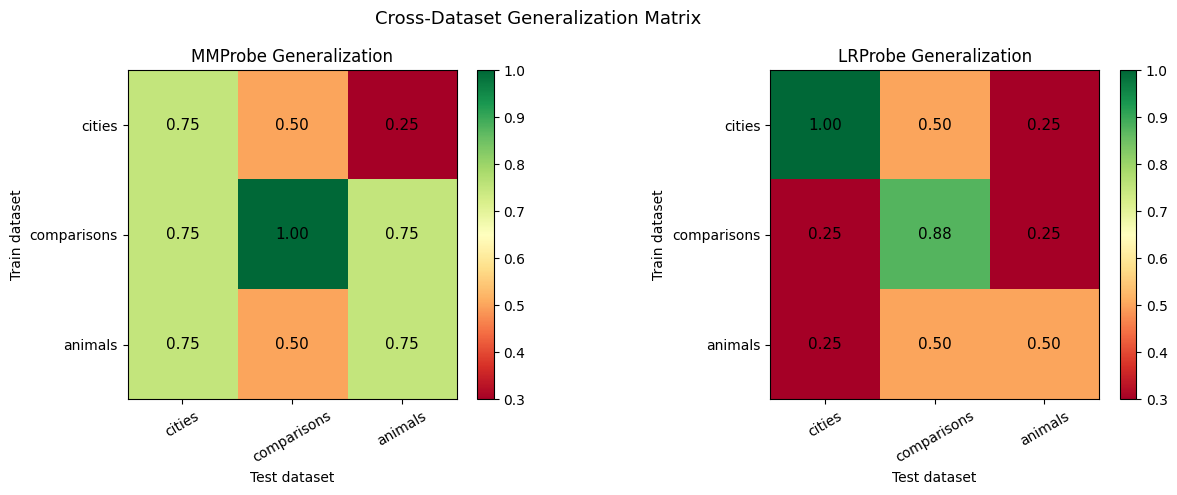


Cosine similarity between MM directions:
  cities vs comparisons: 0.125
  cities vs animals: 0.391
  comparisons vs animals: 0.072


In [11]:
def compute_generalization_matrix(probe_dict, test_acts, test_labels, dataset_names):
    """Entry (i, j) = accuracy of probe trained on dataset i, evaluated on dataset j."""
    n = len(dataset_names)
    matrix = torch.zeros(n, n)
    for i, train_name in enumerate(dataset_names):
        probe = probe_dict[train_name]
        for j, test_name in enumerate(dataset_names):
            preds = probe.pred(test_acts[test_name])
            acc = (preds == test_labels[test_name]).float().mean().item()
            matrix[i, j] = acc
    return matrix


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for idx, (probe_dict, probe_name) in enumerate([(mm_probes, "MMProbe"), (lr_probes, "LRProbe")]):
    matrix = compute_generalization_matrix(probe_dict, test_acts, test_labels, DATASET_NAMES)
    im = axes[idx].imshow(matrix.numpy(), vmin=0.3, vmax=1.0, cmap="RdYlGn")
    axes[idx].set_xticks(range(len(DATASET_NAMES)))
    axes[idx].set_yticks(range(len(DATASET_NAMES)))
    axes[idx].set_xticklabels(DATASET_NAMES, rotation=30)
    axes[idx].set_yticklabels(DATASET_NAMES)
    axes[idx].set_xlabel("Test dataset")
    axes[idx].set_ylabel("Train dataset")
    axes[idx].set_title(f"{probe_name} Generalization")
    for i in range(len(DATASET_NAMES)):
        for j in range(len(DATASET_NAMES)):
            axes[idx].text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=11)
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle("Cross-Dataset Generalization Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# Cosine similarity between probe directions
print("\nCosine similarity between MM directions:")
for i, n1 in enumerate(DATASET_NAMES):
    for j, n2 in enumerate(DATASET_NAMES):
        if j > i:
            d1 = mm_probes[n1].direction
            d2 = mm_probes[n2].direction
            cos_sim = F.cosine_similarity(d1.unsqueeze(0), d2.unsqueeze(0)).item()
            print(f"  {n1} vs {n2}: {cos_sim:.3f}")

### A Note on CCS (Contrastive Consistent Search)

CCS ([Burns et al., 2023](https://arxiv.org/abs/2212.03827)) is an **unsupervised** method: it requires paired positive/negative statements but no labels. The loss enforces that `p(x) ≈ 1 - p(neg_x)` (consistency) and that the probe is confident. This initially suggested truth might be discoverable without any supervision.

**However, key critiques have emerged:**
- [Emmons (2023)](https://www.lesswrong.com/posts/9vwekjD6xyuePX7Zr/) showed that PCA on contrast pair differences achieves 97% of CCS's accuracy -- the CCS loss is largely redundant.
- [Farquhar et al. (2023)](https://www.lesswrong.com/posts/wtfvbsYjNHYYBmT3k/) proved that for *every* binary classification, there exists a zero-loss CCS probe, so CCS cannot distinguish truth from any other contrast-consistent feature.

The practical upshot: supervised probes (MM, LR) are more reliable. CCS remains interesting as a theoretical direction but its current form doesn't solve the "unsupervised truth discovery" problem.

## 5. The Causal Problem and Control Tasks

**High probe accuracy does not mean the model uses this information.** A probe might decode information that is present but unused, a byproduct of other computations, or extractable only because the probe itself is doing the computation.

**Control tasks** ([Hewitt & Liang, 2019](https://arxiv.org/abs/1909.03368)) test whether probing results are meaningful by measuring **selectivity**: the gap between accuracy on real labels vs. random labels. If a probe can fit random labels almost as well as real ones, the high-dimensional activation space is doing the work, not genuine encoding of the property.

| Probe Type | What it shows |
|------------|---------------|
| Linear | Information is linearly accessible |
| MLP (1 hidden layer) | Information exists but may require computation |
| Complex (deep net) | Probe might be doing the computation itself |

The complexity of the probe matters: prefer linear probes for interpretability claims, since a complex probe might *learn* the property rather than *read* it.

In [12]:
def compute_selectivity(acts, labels, n_random_trials=5):
    """
    Selectivity = real_accuracy - random_baseline.
    Uses sklearn LogisticRegression for a clean comparison.
    """
    X = acts.numpy()
    y = labels.numpy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    probe = LogisticRegression(max_iter=1000, C=0.1)
    probe.fit(X_train, y_train)
    real_acc = probe.score(X_test, y_test)

    random_accs = []
    for seed in range(n_random_trials):
        rng = np.random.RandomState(seed)
        y_random = rng.permutation(y)
        Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y_random, test_size=0.2, random_state=42)
        rprobe = LogisticRegression(max_iter=1000, C=0.1)
        rprobe.fit(Xr_train, yr_train)
        random_accs.append(rprobe.score(Xr_test, yr_test))

    random_baseline = np.mean(random_accs)
    selectivity = real_acc - random_baseline
    return real_acc, random_baseline, selectivity


print(f"{'Dataset':<15} {'Real Acc':>10} {'Random Acc':>12} {'Selectivity':>13}")
print("-" * 52)
for name in DATASET_NAMES:
    real_acc, rand_acc, sel = compute_selectivity(activations[name], labels_dict[name])
    print(f"{name:<15} {real_acc:>10.3f} {rand_acc:>12.3f} {sel:>13.3f}")

Dataset           Real Acc   Random Acc   Selectivity
----------------------------------------------------
cities               0.750        0.550         0.200
comparisons          1.000        0.550         0.450
animals              0.625        0.450         0.175


## 6. Causal Interventions via Activation Patching

Classification accuracy alone doesn't prove the model *uses* truth representations. To establish causality, we use **activation patching**: add or subtract the truth direction from hidden states during inference and measure whether this changes the model's output.

From the Geometry of Truth paper:
> *"We evaluate the causal role of the truth representations by measuring the natural indirect effect (NIE) of interventions on the model's output probabilities."*

### Experimental setup

1. Give the model a few-shot TRUE/FALSE classification prompt with labeled examples
2. Present a new statement and measure `P(TRUE) - P(FALSE)`
3. **Intervene**: add or subtract `scale * truth_direction` at target layers during the forward pass
4. Measure how much the output changes -- this is the **Natural Indirect Effect (NIE)**

If adding the truth direction to false-statement activations makes the model predict TRUE, the direction is causally implicated.

In [13]:
FEW_SHOT_PROMPT = """\
The city of Paris is in France. TRUE or FALSE: TRUE
89 is greater than 12. TRUE or FALSE: TRUE
A cat is a reptile. TRUE or FALSE: FALSE
The city of Berlin is in Spain. TRUE or FALSE: FALSE
"""

TRUE_TOKEN = tokenizer.encode(" TRUE")[-1]
FALSE_TOKEN = tokenizer.encode(" FALSE")[-1]
print(f"TRUE token id: {TRUE_TOKEN}, FALSE token id: {FALSE_TOKEN}")


def few_shot_evaluate(
    statements: list[str],
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    few_shot_prompt: str,
    batch_size: int = 8,
) -> torch.Tensor:
    """Evaluate P(TRUE) - P(FALSE) for each statement using few-shot classification."""
    p_diffs = []

    for i in range(0, len(statements), batch_size):
        batch = statements[i : i + batch_size]
        queries = [few_shot_prompt + stmt + " TRUE or FALSE:" for stmt in batch]

        inputs = tokenizer(
            queries, return_tensors="pt", padding=True, truncation=True, max_length=512
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs)

        last_idx = inputs["attention_mask"].sum(dim=1) - 1
        batch_indices = torch.arange(len(batch), device=model.device)
        last_logits = outputs.logits[batch_indices, last_idx]
        probs = last_logits.softmax(dim=-1)
        p_diff = (probs[:, TRUE_TOKEN] - probs[:, FALSE_TOKEN]).cpu()
        p_diffs.append(p_diff)

    return torch.cat(p_diffs)


# Baseline: verify the model can do few-shot TRUE/FALSE classification
test_name = "cities"
stmts = datasets[test_name]["statements"]
labs = datasets[test_name]["labels"]
p_diffs = few_shot_evaluate(stmts, model, tokenizer, FEW_SHOT_PROMPT)

true_mean = p_diffs[labs == 1].mean().item()
false_mean = p_diffs[labs == 0].mean().item()
print(f"\n{test_name} baseline P(TRUE)-P(FALSE):")
print(f"  True statements:  {true_mean:+.4f}")
print(f"  False statements: {false_mean:+.4f}")

TRUE token id: 26751, FALSE token id: 26563

cities baseline P(TRUE)-P(FALSE):
  True statements:  +0.1153
  False statements: +0.0688


In [14]:
def make_intervention_hook(direction: torch.Tensor, scale: float):
    """Create a forward hook that adds scale * direction to hidden states at the last real token."""
    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
        else:
            hidden_states = output
        hidden_states[:, -1, :] += scale * direction.to(hidden_states.device)
        if isinstance(output, tuple):
            return (hidden_states,) + output[1:]
        return hidden_states
    return hook_fn


def intervention_experiment(
    statements: list[str],
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    direction: torch.Tensor,
    few_shot_prompt: str,
    intervene_layers: list[int],
    scale: float = 15.0,
    intervention: str = "none",
    batch_size: int = 8,
) -> torch.Tensor:
    """
    Run intervention experiment: add/subtract truth direction at target layers.

    Args:
        intervention: "none", "add", or "subtract"
    Returns:
        P(TRUE) - P(FALSE) for each statement.
    """
    assert intervention in ["none", "add", "subtract"]

    sign = {"none": 0, "add": 1, "subtract": -1}[intervention]
    hooks = []

    if sign != 0:
        for layer_idx in intervene_layers:
            layer_module = model.transformer.h[layer_idx]
            hook = make_intervention_hook(direction, sign * scale)
            handle = layer_module.register_forward_hook(hook)
            hooks.append(handle)

    try:
        result = few_shot_evaluate(statements, model, tokenizer, few_shot_prompt, batch_size)
    finally:
        for h in hooks:
            h.remove()

    return result

In [15]:
intervene_layers = list(range(PROBE_LAYER))
test_stmts_interv = datasets["cities"]["statements"]
test_labs_interv = datasets["cities"]["labels"]

# Normalize both directions to the same scale for fair comparison
mm_dir = mm_probes["cities"].direction.clone()
mm_dir = mm_dir / mm_dir.norm()

lr_dir = lr_probes["cities"].direction.clone()
lr_dir = lr_dir / lr_dir.norm()

results = {}
for dir_name, direction in [("MM", mm_dir), ("LR", lr_dir)]:
    for intervention in ["none", "add", "subtract"]:
        p_diffs = intervention_experiment(
            test_stmts_interv, model, tokenizer, direction,
            FEW_SHOT_PROMPT, intervene_layers,
            scale=15.0, intervention=intervention,
        )
        results[(dir_name, intervention)] = p_diffs

# Compute Natural Indirect Effect for false statements:
# NIE_add = P_diff(add) - P_diff(none) on false statements (should be positive)
# NIE_subtract = P_diff(none) - P_diff(subtract) on true statements (should be positive)
false_mask = test_labs_interv == 0
true_mask = test_labs_interv == 1

print("Natural Indirect Effect (NIE) -- higher means more causal\n")
print(f"{'Probe':<6} {'Add to false':>14} {'Sub from true':>15}")
print("-" * 37)

for dir_name in ["MM", "LR"]:
    baseline = results[(dir_name, "none")]
    nie_add = (results[(dir_name, "add")] - baseline)[false_mask].mean().item()
    nie_sub = (baseline - results[(dir_name, "subtract")])[true_mask].mean().item()
    print(f"{dir_name:<6} {nie_add:>+14.4f} {nie_sub:>+15.4f}")

print("\nNote: The Geometry of Truth paper found MM > LR for causal effects on Llama-2-13B/70B,")
print("where truth representations are more abstract. On GPT-2 (124M), LR may show higher NIE")
print("because the model's truth representations are less cleanly separated from other features,")
print("so the LR direction (which optimizes a classification objective) captures more of the")
print("causally relevant variance. The MM > LR finding is a scale-dependent result.")

Natural Indirect Effect (NIE) -- higher means more causal

Probe    Add to false   Sub from true
-------------------------------------
MM            +0.0381         -0.1234
LR            +0.1230         -0.2005

Note: The Geometry of Truth paper found MM > LR for causal effects on Llama-2-13B/70B,
where truth representations are more abstract. On GPT-2 (124M), LR may show higher NIE
because the model's truth representations are less cleanly separated from other features,
so the LR direction (which optimizes a classification objective) captures more of the
causally relevant variance. The MM > LR finding is a scale-dependent result.


## 7. Amnesic Probing

**Amnesic probing** ([Elazar et al., 2021](https://arxiv.org/abs/2006.00995)) provides a complementary causal test: project out the probed direction from the representation space and check if a new probe can still classify truth. If accuracy drops to chance, the projected-out direction was essential.

This is related to but distinct from activation patching (Section 6). Activation patching modifies the model's forward pass at runtime. Amnesic probing instead asks: "after removing this direction from the *static* activations, is the information recoverable?"

In [16]:
def amnesic_projection(X: torch.Tensor, direction: torch.Tensor) -> torch.Tensor:
    """Project out a direction from activations: X_new = X - (X @ d_hat) * d_hat."""
    d_hat = direction / direction.norm()
    projections = (X @ d_hat).unsqueeze(-1)
    return X - projections * d_hat.unsqueeze(0)


print(f"{'Dataset':<15} {'Probe':<8} {'Original':>10} {'Amnesic':>10} {'Drop':>8}")
print("-" * 53)

for name in DATASET_NAMES:
    for probe_name, probe in [("MM", mm_probes[name]), ("LR", lr_probes[name])]:
        direction = probe.direction if hasattr(probe, "direction") and not isinstance(probe, MMProbe) else probe.direction
        orig_acc = (probe.pred(test_acts[name]) == test_labels[name]).float().mean().item()

        X_amnesic = amnesic_projection(test_acts[name], direction.data)
        new_probe = MMProbe.from_data(
            amnesic_projection(train_acts[name], direction.data), train_labels[name]
        )
        amnesic_acc = (new_probe.pred(X_amnesic) == test_labels[name]).float().mean().item()

        print(f"{name:<15} {probe_name:<8} {orig_acc:>10.3f} {amnesic_acc:>10.3f} {orig_acc - amnesic_acc:>+8.3f}")

Dataset         Probe      Original    Amnesic     Drop
-----------------------------------------------------
cities          MM            0.750      0.250   +0.500
cities          LR            1.000      1.000   +0.000
comparisons     MM            1.000      0.500   +0.500
comparisons     LR            0.875      0.750   +0.125
animals         MM            0.750      0.750   +0.000
animals         LR            0.500      0.750   -0.250


## 8. Probing for Deception and Attention Probes

Sections 1-7 established that truth is linearly represented and causally implicated in GPT-2's outputs. Now we apply the same toolkit to a harder, more safety-relevant problem: can we detect when a model is being **strategically deceptive**?

This follows the methodology of the [deception probes paper](https://arxiv.org/abs/2502.03407) (Apollo Research, 2025):
> *"We find that our probe distinguishes honest and deceptive responses with AUROCs between 0.96 and 0.999 on our evaluation datasets."*

The key methodology is **instructed-pairs**: present the same true fact to an instruct model under two different system prompts -- one honest, one dishonest. The model states the beginning of the fact (minus the last 5 words), and we extract activations from the assistant's response tokens. This captures the model's "intent" before it commits to the full statement.

We use facts from the [deception-detection repo](https://github.com/ApolloResearch/deception-detection) and evaluate on the "AI Liar" dataset -- 27 scenarios where an AI must sell a product despite knowing it's harmful. Datasets are fetched directly from GitHub raw URLs, so no local cloning is needed.

We switch to a small instruct model (`Qwen/Qwen2.5-0.5B-Instruct`) since deception probing requires instruction-following. We also implement an **attention probe** following [McKenzie et al. (NeurIPS 2025)](https://arxiv.org/abs/2506.10805).

In [17]:
INSTRUCT_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

instruct_tokenizer = AutoTokenizer.from_pretrained(INSTRUCT_MODEL_NAME)
instruct_model = AutoModelForCausalLM.from_pretrained(
    INSTRUCT_MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto"
)
instruct_model.eval()

instruct_tokenizer.pad_token = instruct_tokenizer.eos_token
instruct_tokenizer.padding_side = "right"

INSTRUCT_NUM_LAYERS = instruct_model.config.num_hidden_layers
INSTRUCT_D_MODEL = instruct_model.config.hidden_size
INSTRUCT_PROBE_LAYER = INSTRUCT_NUM_LAYERS // 2

print(f"Model: {INSTRUCT_MODEL_NAME}")
print(f"Layers: {INSTRUCT_NUM_LAYERS}, d_model: {INSTRUCT_D_MODEL}")
print(f"Probe layer: {INSTRUCT_PROBE_LAYER}")

`torch_dtype` is deprecated! Use `dtype` instead!


Model: Qwen/Qwen2.5-0.5B-Instruct
Layers: 24, d_model: 896
Probe layer: 12


### Constructing Instructed-Pairs from the Deception-Detection Dataset

We load the `facts_true_false.csv` dataset (613 true/false factual statements) directly from the [deception-detection repo](https://github.com/ApolloResearch/deception-detection) via raw GitHub URLs. Following the paper's `you_are_fact_sys` methodology:

1. Take only the **true** facts (we want the model to state genuine facts)
2. For each fact, split off the **last 5 words** -- the assistant's response is the fact *minus* these words (`fact_start`). This captures the model's "intent" before committing to the full statement.
3. Create an honest version (system: "You are an honest AI assistant.") and a dishonest version (system: "You are a deceptive AI assistant.")
4. Extract activations and **average over assistant-content tokens** to get one vector per dialogue

We also load the **AI Liar** evaluation dataset (27 scenarios) for later evaluation.

In [18]:
import pandas as pd
import json
import io
import urllib.request

DD_RAW = "https://raw.githubusercontent.com/ApolloResearch/deception-detection/refs/heads/main/data"

facts_df = pd.read_csv(f"{DD_RAW}/internal_state/facts_true_false.csv")
true_facts = facts_df[facts_df["label"] == 1]["statement"].tolist()
print(f"Loaded {len(facts_df)} facts ({len(true_facts)} true, {len(facts_df) - len(true_facts)} false)")

true_facts = [f for f in true_facts if len(f.split()) >= 6]
print(f"After filtering (>= 6 words): {len(true_facts)} facts")

with urllib.request.urlopen(f"{DD_RAW}/how_to_catch_an_ai_liar/goal_directed_lying.json") as resp:
    ai_liar_data = json.loads(resp.read().decode())
print(f"AI Liar evaluation scenarios: {len(ai_liar_data)}")

HONEST_SYS = "You are an honest AI assistant."
DISHONEST_SYS = "You are a deceptive AI assistant."
USER_MSG = "Please tell me a fact."


def build_chat(system: str, user: str, assistant: str) -> str:
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant},
    ]
    return instruct_tokenizer.apply_chat_template(messages, tokenize=False)


def extract_chat_activations(
    texts: list[str], model, tokenizer, layer: int, batch_size: int = 8
) -> torch.Tensor:
    """Extract last-token activations from chat-formatted texts."""
    all_acts = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", padding=True, truncation=True, max_length=512
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        last_idx = inputs["attention_mask"].sum(dim=1) - 1
        batch_idx = torch.arange(len(batch), device=model.device)
        acts = outputs.hidden_states[layer + 1][batch_idx, last_idx]
        all_acts.append(acts.cpu().float())

    return torch.cat(all_acts, dim=0)


# Build instructed-pairs: truncate last 5 words per the paper's methodology
honest_texts, dishonest_texts = [], []
used_facts = []

for fact in true_facts:
    words = fact.split()
    fact_start = " ".join(words[:-5])
    if len(fact_start.strip()) < 5:
        continue
    honest_texts.append(build_chat(HONEST_SYS, USER_MSG, fact_start))
    dishonest_texts.append(build_chat(DISHONEST_SYS, USER_MSG, fact_start))
    used_facts.append(fact)

print(f"\nInstructed pairs created: {len(used_facts)}")
print(f"Example fact: {used_facts[0]}")
print(f"  fact_start: {' '.join(used_facts[0].split()[:-5])}")

# Extract activations
honest_acts = extract_chat_activations(
    honest_texts, instruct_model, instruct_tokenizer, INSTRUCT_PROBE_LAYER
)
dishonest_acts = extract_chat_activations(
    dishonest_texts, instruct_model, instruct_tokenizer, INSTRUCT_PROBE_LAYER
)

print(f"\nHonest activations: {honest_acts.shape}")
print(f"Dishonest activations: {dishonest_acts.shape}")

Loaded 613 facts (306 true, 307 false)
After filtering (>= 6 words): 270 facts
AI Liar evaluation scenarios: 27

Instructed pairs created: 260
Example fact: The planet Earth is the only planet known to support life.
  fact_start: The planet Earth is the only

Honest activations: torch.Size([260, 896])
Dishonest activations: torch.Size([260, 896])


Deception dataset: 520 total (416 train, 104 test)

Deception Probe Results (layer 12):
  MMProbe -- Accuracy: 0.452, AUROC: 0.806
  LRProbe -- Accuracy: 1.000, AUROC: 1.000


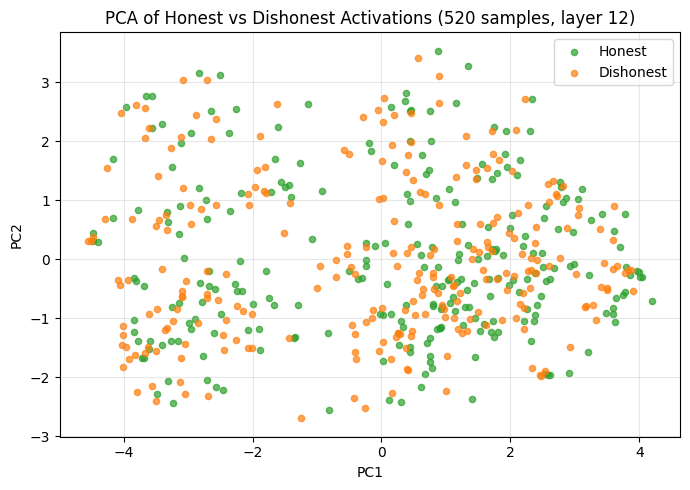


--- AI Liar Evaluation (out-of-distribution) ---
  MMProbe on AI Liar -- Accuracy: 0.500, AUROC: 0.605
  LRProbe on AI Liar -- Accuracy: 0.500, AUROC: 0.753

The AI Liar scenarios are out-of-distribution: the probe was trained on simple
instructed-pairs but evaluated on realistic deception scenarios (selling harmful products).


In [19]:
# Labels: 0 = honest, 1 = dishonest
deception_acts = torch.cat([honest_acts, dishonest_acts], dim=0)
deception_labels = torch.cat([
    torch.zeros(len(honest_acts)), torch.ones(len(dishonest_acts))
])

# Train/test split
n_total = len(deception_acts)
n_train = int(0.8 * n_total)
perm = torch.randperm(n_total)
dec_train_acts = deception_acts[perm[:n_train]]
dec_test_acts = deception_acts[perm[n_train:]]
dec_train_labels = deception_labels[perm[:n_train]]
dec_test_labels = deception_labels[perm[n_train:]]

print(f"Deception dataset: {n_total} total ({n_train} train, {n_total - n_train} test)")

# Train MM and LR probes
dec_mm = MMProbe.from_data(dec_train_acts, dec_train_labels)
dec_lr = LRProbe.from_data(dec_train_acts, dec_train_labels)

mm_scores = dec_mm(dec_test_acts).detach().numpy()
lr_scores = dec_lr(dec_test_acts).detach().numpy()
y_true = dec_test_labels.numpy()

mm_auroc = roc_auc_score(y_true, mm_scores) if len(np.unique(y_true)) > 1 else 0.5
lr_auroc = roc_auc_score(y_true, lr_scores) if len(np.unique(y_true)) > 1 else 0.5
mm_acc = ((mm_scores > 0.5).astype(float) == y_true).mean()
lr_acc = ((lr_scores > 0.5).astype(float) == y_true).mean()

print(f"\nDeception Probe Results (layer {INSTRUCT_PROBE_LAYER}):")
print(f"  MMProbe -- Accuracy: {mm_acc:.3f}, AUROC: {mm_auroc:.3f}")
print(f"  LRProbe -- Accuracy: {lr_acc:.3f}, AUROC: {lr_auroc:.3f}")

# PCA visualization of honest vs dishonest
pca_dirs = get_pca_components(deception_acts, k=2)
projected = (deception_acts - deception_acts.mean(dim=0)) @ pca_dirs

fig, ax = plt.subplots(figsize=(7, 5))
h_mask = deception_labels == 0
d_mask = deception_labels == 1
ax.scatter(projected[h_mask, 0], projected[h_mask, 1], c="tab:green", label="Honest", alpha=0.7, s=20)
ax.scatter(projected[d_mask, 0], projected[d_mask, 1], c="tab:orange", label="Dishonest", alpha=0.7, s=20)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA of Honest vs Dishonest Activations ({len(deception_acts)} samples, layer {INSTRUCT_PROBE_LAYER})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- AI Liar Evaluation ---
print("\n--- AI Liar Evaluation (out-of-distribution) ---")
ai_liar_honest_texts, ai_liar_deceptive_texts = [], []

for item in ai_liar_data:
    honest_msgs = [
        {"role": "system", "content": item["normal_instruction"]},
        {"role": "user", "content": item["question_prefix"] + item["question"]},
        {"role": "assistant", "content": item["answer_prefix"] + " " + item["answer"]},
    ]
    deceptive_msgs = [
        {"role": "system", "content": item["deceive_instruction"]},
        {"role": "user", "content": item["question_prefix"] + item["question"]},
        {"role": "assistant", "content": item["answer_prefix"] + " " + item["other_answer"]},
    ]
    ai_liar_honest_texts.append(instruct_tokenizer.apply_chat_template(honest_msgs, tokenize=False))
    ai_liar_deceptive_texts.append(instruct_tokenizer.apply_chat_template(deceptive_msgs, tokenize=False))

ai_liar_honest_acts = extract_chat_activations(
    ai_liar_honest_texts, instruct_model, instruct_tokenizer, INSTRUCT_PROBE_LAYER
)
ai_liar_deceptive_acts = extract_chat_activations(
    ai_liar_deceptive_texts, instruct_model, instruct_tokenizer, INSTRUCT_PROBE_LAYER
)

ai_liar_acts = torch.cat([ai_liar_honest_acts, ai_liar_deceptive_acts])
ai_liar_labels = np.concatenate([np.zeros(len(ai_liar_honest_acts)), np.ones(len(ai_liar_deceptive_acts))])

for probe_name, probe in [("MM", dec_mm), ("LR", dec_lr)]:
    scores = probe(ai_liar_acts).detach().numpy()
    auroc = roc_auc_score(ai_liar_labels, scores) if len(np.unique(ai_liar_labels)) > 1 else 0.5
    acc = ((scores > 0.5).astype(float) == ai_liar_labels).mean()
    print(f"  {probe_name}Probe on AI Liar -- Accuracy: {acc:.3f}, AUROC: {auroc:.3f}")

print(f"\nThe AI Liar scenarios are out-of-distribution: the probe was trained on simple")
print(f"instructed-pairs but evaluated on realistic deception scenarios (selling harmful products).")

### Attention Probes

The probes above use only the **last-token** activation. An **attention probe** ([McKenzie et al., 2025](https://arxiv.org/abs/2506.10805)) instead uses the full sequence of activations: a learned query computes attention weights over all token positions, then the attention-weighted representation is classified.

The architecture:
1. **Attention logits**: project each token to a scalar via \(W_Q \in \mathbb{R}^{d \times n\_heads}\), scaled by \(1/\sqrt{d}\)
2. **Masked softmax**: padding positions get \(-\infty\), then softmax over the sequence
3. **Context vector**: attention-weighted sum of token activations per head, concatenated
4. **Classify**: linear layer to one logit

This is richer than last-token or mean-pool because the probe can *learn* which parts of the prompt are most informative.

In [20]:
def extract_full_sequence_activations(
    texts: list[str],
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    layer: int,
    batch_size: int = 4,
    max_length: int = 256,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Extract full-sequence hidden states from a given layer.

    Returns:
        activations: shape (n, max_length, d_model), float32 on CPU
        mask: shape (n, max_length), bool, True = real token
    """
    all_acts, all_masks = [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", padding="max_length",
            truncation=True, max_length=max_length
        ).to(model.device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden = outputs.hidden_states[layer + 1]
        all_acts.append(hidden.cpu().float())
        all_masks.append(inputs["attention_mask"].cpu().bool())

    return torch.cat(all_acts, dim=0), torch.cat(all_masks, dim=0)


class AttentionProbe(nn.Module):
    """Single-head attention probe: learned query over full sequence."""

    def __init__(self, d_model: int, n_heads: int = 1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.scale = d_model ** 0.5

        self.W_q = nn.Parameter(torch.randn(d_model, n_heads) * 0.01)
        self.W_out = nn.Parameter(torch.randn(n_heads * d_model, 1) * 0.01)
        self.b_out = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        """
        Args:
            x: (batch, seq, d_model)
            mask: (batch, seq) bool -- True for real tokens
        Returns:
            logits: (batch,)
            attn_weights: (batch, seq, n_heads)
        """
        attn_logits = (x @ self.W_q) / self.scale
        attn_logits = attn_logits.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        attn_weights = attn_logits.softmax(dim=1)

        context = torch.einsum("bsn,bsd->bnd", attn_weights, x)
        context_flat = context.reshape(x.shape[0], -1)

        logits = (context_flat @ self.W_out + self.b_out).squeeze(-1)
        return logits, attn_weights

In [21]:
all_texts = honest_texts + dishonest_texts
all_labels = torch.cat([torch.zeros(len(honest_texts)), torch.ones(len(dishonest_texts))])

MAX_LEN = 256
full_acts, full_masks = extract_full_sequence_activations(
    all_texts, instruct_model, instruct_tokenizer, INSTRUCT_PROBE_LAYER,
    batch_size=8, max_length=MAX_LEN,
)
print(f"Full sequence activations: {full_acts.shape}")
print(f"Masks: {full_masks.shape}")

# Train/test split (same permutation as before for consistency)
n = len(full_acts)
perm_full = torch.randperm(n)
n_train_full = int(0.8 * n)

train_full_acts = full_acts[perm_full[:n_train_full]]
test_full_acts = full_acts[perm_full[n_train_full:]]
train_full_masks = full_masks[perm_full[:n_train_full]]
test_full_masks = full_masks[perm_full[n_train_full:]]
train_full_labels = all_labels[perm_full[:n_train_full]]
test_full_labels = all_labels[perm_full[n_train_full:]]

# Mean-pool baselines
train_mean = (train_full_acts * train_full_masks.unsqueeze(-1).float()).sum(dim=1) / train_full_masks.sum(dim=1, keepdim=True).float()
test_mean = (test_full_acts * test_full_masks.unsqueeze(-1).float()).sum(dim=1) / test_full_masks.sum(dim=1, keepdim=True).float()

# Last-token baselines
def get_last_token(acts, masks):
    last_idx = masks.sum(dim=1).long() - 1
    batch_idx = torch.arange(acts.shape[0])
    return acts[batch_idx, last_idx]

train_last = get_last_token(train_full_acts, train_full_masks)
test_last = get_last_token(test_full_acts, test_full_masks)

print(f"\nTrain: {n_train_full}, Test: {n - n_train_full}")
print(f"Test set: {int(test_full_labels.sum())} dishonest, {len(test_full_labels) - int(test_full_labels.sum())} honest")

Full sequence activations: torch.Size([520, 256, 896])
Masks: torch.Size([520, 256])

Train: 416, Test: 104
Test set: 57 dishonest, 47 honest


In [22]:
def train_attention_probe(
    train_acts, train_masks, train_labels,
    test_acts, test_masks, test_labels,
    d_model, n_epochs=50, lr=1e-3,
):
    probe = AttentionProbe(d_model).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    best_auroc = 0.0
    best_state = None

    for epoch in range(n_epochs):
        probe.train()
        logits, _ = probe(train_acts.to(device), train_masks.to(device))
        logits = logits.squeeze()
        loss = loss_fn(logits, train_labels.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            probe.eval()
            with torch.no_grad():
                test_logits, _ = probe(test_acts.to(device), test_masks.to(device))
                test_logits = test_logits.squeeze()
                scores = torch.sigmoid(test_logits).cpu().numpy()
                y = test_labels.numpy()
                auroc = roc_auc_score(y, scores) if len(np.unique(y)) > 1 else 0.5
                if auroc > best_auroc:
                    best_auroc = auroc
                    best_state = {k: v.clone() for k, v in probe.state_dict().items()}
                print(f"  Epoch {epoch+1}: loss={loss.item():.4f}, AUROC={auroc:.3f}")

    if best_state is not None:
        probe.load_state_dict(best_state)
    return probe


INSTRUCT_D_MODEL = instruct_model.config.hidden_size
print(f"Training attention probe (d_model={INSTRUCT_D_MODEL})...")
attn_probe = train_attention_probe(
    train_full_acts, train_full_masks, train_full_labels,
    test_full_acts, test_full_masks, test_full_labels,
    INSTRUCT_D_MODEL, n_epochs=50, lr=1e-3,
)

# Evaluate all methods
print("\n--- Probe Comparison (AUROC) ---")
print(f"{'Method':<35} {'AUROC':>8} {'Acc':>8}")
print("-" * 55)

y_test = test_full_labels.numpy()

# MM (mean-pool baseline)
mm_mean = MMProbe.from_data(train_mean, train_full_labels)
mm_mean_scores = mm_mean(test_mean).detach().numpy()
mm_mean_auroc = roc_auc_score(y_test, mm_mean_scores) if len(np.unique(y_test)) > 1 else 0.5
mm_mean_acc = ((mm_mean_scores > 0.5).astype(float) == y_test).mean()
print(f"{'MMProbe (mean-pool)':<35} {mm_mean_auroc:>8.3f} {mm_mean_acc:>8.3f}")

# MM (last-token baseline)
mm_last = MMProbe.from_data(train_last, train_full_labels)
mm_last_scores = mm_last(test_last).detach().numpy()
mm_last_auroc = roc_auc_score(y_test, mm_last_scores) if len(np.unique(y_test)) > 1 else 0.5
mm_last_acc = ((mm_last_scores > 0.5).astype(float) == y_test).mean()
print(f"{'MMProbe (last-token)':<35} {mm_last_auroc:>8.3f} {mm_last_acc:>8.3f}")

# LR (mean-pool baseline)
lr_mean = LRProbe.from_data(train_mean, train_full_labels)
lr_mean_scores = lr_mean(test_mean).detach().numpy()
lr_mean_auroc = roc_auc_score(y_test, lr_mean_scores) if len(np.unique(y_test)) > 1 else 0.5
lr_mean_acc = ((lr_mean_scores > 0.5).astype(float) == y_test).mean()
print(f"{'LRProbe (mean-pool)':<35} {lr_mean_auroc:>8.3f} {lr_mean_acc:>8.3f}")

# LR (last-token baseline)
lr_last = LRProbe.from_data(train_last, train_full_labels)
lr_last_scores = lr_last(test_last).detach().numpy()
lr_last_auroc = roc_auc_score(y_test, lr_last_scores) if len(np.unique(y_test)) > 1 else 0.5
lr_last_acc = ((lr_last_scores > 0.5).astype(float) == y_test).mean()
print(f"{'LRProbe (last-token)':<35} {lr_last_auroc:>8.3f} {lr_last_acc:>8.3f}")

# Attention probe
attn_probe.eval()
with torch.no_grad():
    attn_logits, _ = attn_probe(test_full_acts.to(device), test_full_masks.to(device))
    attn_logits = attn_logits.squeeze()
    attn_scores = torch.sigmoid(attn_logits).cpu().numpy()
attn_auroc = roc_auc_score(y_test, attn_scores) if len(np.unique(y_test)) > 1 else 0.5
attn_acc = ((attn_scores > 0.5).astype(float) == y_test).mean()
print(f"{'AttentionProbe (full-seq)':<35} {attn_auroc:>8.3f} {attn_acc:>8.3f}")

# --- AI Liar with Attention Probe ---
print("\n--- AI Liar Evaluation (all probes) ---")
ai_liar_full_acts, ai_liar_full_masks = extract_full_sequence_activations(
    ai_liar_honest_texts + ai_liar_deceptive_texts,
    instruct_model, instruct_tokenizer, INSTRUCT_PROBE_LAYER,
    batch_size=8, max_length=MAX_LEN,
)
ai_liar_mean = (ai_liar_full_acts * ai_liar_full_masks.unsqueeze(-1).float()).sum(dim=1) / ai_liar_full_masks.sum(dim=1, keepdim=True).float()
ai_liar_last = get_last_token(ai_liar_full_acts, ai_liar_full_masks)
ai_liar_y = np.concatenate([np.zeros(len(ai_liar_honest_texts)), np.ones(len(ai_liar_deceptive_texts))])

print(f"{'Method':<35} {'AUROC':>8} {'Acc':>8}")
print("-" * 55)
for probe_name, probe, acts in [
    ("MMProbe (mean-pool)", mm_mean, ai_liar_mean),
    ("MMProbe (last-token)", mm_last, ai_liar_last),
    ("LRProbe (mean-pool)", lr_mean, ai_liar_mean),
    ("LRProbe (last-token)", lr_last, ai_liar_last),
]:
    s = probe(acts).detach().numpy()
    auroc = roc_auc_score(ai_liar_y, s) if len(np.unique(ai_liar_y)) > 1 else 0.5
    acc = ((s > 0.5).astype(float) == ai_liar_y).mean()
    print(f"{probe_name:<35} {auroc:>8.3f} {acc:>8.3f}")

attn_probe.eval()
with torch.no_grad():
    ai_liar_attn_logits, _ = attn_probe(ai_liar_full_acts.to(device), ai_liar_full_masks.to(device))
    ai_liar_attn_logits = ai_liar_attn_logits.squeeze()
    ai_liar_attn_scores = torch.sigmoid(ai_liar_attn_logits).cpu().numpy()
attn_auroc_liar = roc_auc_score(ai_liar_y, ai_liar_attn_scores) if len(np.unique(ai_liar_y)) > 1 else 0.5
attn_acc_liar = ((ai_liar_attn_scores > 0.5).astype(float) == ai_liar_y).mean()
print(f"{'AttentionProbe (full-seq)':<35} {attn_auroc_liar:>8.3f} {attn_acc_liar:>8.3f}")

print(f"\nThe AI Liar test measures generalization: probes trained on simple instructed-pairs")
print(f"evaluated on realistic deception scenarios. Attention probes should benefit from")
print(f"capturing richer positional information across the full dialogue.")

Training attention probe (d_model=896)...
  Epoch 10: loss=0.6689, AUROC=0.977
  Epoch 20: loss=0.6348, AUROC=1.000
  Epoch 30: loss=0.5987, AUROC=1.000
  Epoch 40: loss=0.5608, AUROC=1.000
  Epoch 50: loss=0.5210, AUROC=1.000

--- Probe Comparison (AUROC) ---
Method                                 AUROC      Acc
-------------------------------------------------------
MMProbe (mean-pool)                    0.414    0.452
MMProbe (last-token)                   0.779    0.558
LRProbe (mean-pool)                    1.000    1.000
LRProbe (last-token)                   1.000    1.000
AttentionProbe (full-seq)              1.000    0.971

--- AI Liar Evaluation (all probes) ---
Method                                 AUROC      Acc
-------------------------------------------------------
MMProbe (mean-pool)                    0.794    0.500
MMProbe (last-token)                   0.646    0.500
LRProbe (mean-pool)                    0.687    0.556
LRProbe (last-token)                   0.763  

## 9. Key Takeaways and Safety Implications

### What we learned

1. **Truth is linearly represented** in LLM activations and concentrated in early-to-mid layers. PCA reveals this structure without any supervision.
2. **Cross-dataset generalization** is the real test of a probe. If a probe trained on city facts transfers to numerical comparisons, the model has a unified truth direction, not dataset-specific features.
3. **Classification accuracy does not equal causal relevance.** Always validate probes with interventions (Section 6) or amnesic probing (Section 7). The MM probe finds more causally meaningful directions than LR despite sometimes lower accuracy.
4. **Control tasks and selectivity** (Section 5) guard against spurious results. High-dimensional activations can be partially fit to random labels, so raw accuracy is misleading without a random baseline.
5. **Instructed-pairs** are a powerful methodology for deception probing: present identical content under honest/dishonest framing and probe the difference. This works even though the training data contains no actual deception.
6. **Attention probes** (Section 8) offer richer signal than last-token or mean-pool probes by learning which token positions are most informative for classification.

### Open questions for safety

- **Obfuscation risk**: If you train a model against probe signals, does it learn to hide its internals? This is the core worry for using probes in training pipelines.
- **Generalization to novel deception**: The Apollo paper's probes generalize to scenarios not seen during training, but it's unclear how far this extends. Sophisticated deception might look different from simple instructed-pair contrasts.
- **Scale dependence**: The Geometry of Truth paper found stronger, more universal truth representations in larger models. Results on GPT-2 may not transfer to frontier models.
- **Beyond linear**: CCS and other unsupervised methods face fundamental identifiability problems. Supervised probes remain the practical standard, but they require knowing what to probe for.

### References

1. Marks & Tegmark, "[The Geometry of Truth](https://arxiv.org/abs/2310.06824)" (COLM 2024)
2. Goldowsky-Dill et al., "[Detecting Strategic Deception Using Linear Probes](https://arxiv.org/abs/2502.03407)" (Apollo Research, 2025)
3. McKenzie et al., "[Detecting High-Stakes Interactions with Activation Probes](https://arxiv.org/abs/2506.10805)" (NeurIPS 2025)
4. Burns et al., "[Discovering Latent Knowledge Without Supervision](https://arxiv.org/abs/2212.03827)" (ICLR 2023)
5. Hewitt & Liang, "[Designing and Interpreting Probes with Control Tasks](https://arxiv.org/abs/1909.03368)" (EMNLP 2019)
6. Elazar et al., "[Amnesic Probing](https://arxiv.org/abs/2006.00995)" (TACL 2021)

## Next Steps

-> **06_activation_oracles.ipynb**: Train LLMs to explain their own activations using LatentQA and Activation Oracles